# Classification: Benchmarking
- Loads YOLO, ViT and CNN models
- Test the models on the test set (from the '30kds')
- Plots confusion matrix for each model
- Compare acc and loss
- Compares pre-trained vs 'raw' models

In [1]:
%matplotlib inline
import os
import torch
import timm
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, accuracy_score
from ultralytics import YOLO
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_dir = "30kds/test"

In [2]:
# Define transformation for CNN and ViT
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_dataset = ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
class_names = test_dataset.classes  # ['Fake', 'Real']

print(test_dataset.class_to_idx)  # Should show {"Fake": 0, "Real": 1}

{'Fake': 0, 'Real': 1}


In [3]:
# Load Models
def load_cnn(model_path):
    class CustomResNet(nn.Module):
        def __init__(self):
            super(CustomResNet, self).__init__()
            self.model = models.resnet18(weights=None)
            num_ftrs = self.model.fc.in_features
            self.model.fc = nn.Linear(num_ftrs, 2)
        
        def forward(self, x):
            return self.model(x)

    model = CustomResNet()
    
    # Load state dict and examine keys to help debug
    state_dict = torch.load(model_path, map_location=device)
    print("State dict keys:", list(state_dict.keys())[:5])  # Print first 5 keys
    
    # Try loading without modifying keys first
    try:
        model.load_state_dict(state_dict)
    except Exception as e:
        print(f"Direct loading failed: {e}")
        # If that fails, try the key transformation
        new_state_dict = {k.replace("model.", ""): v for k, v in state_dict.items()}
        print("New state dict keys:", list(new_state_dict.keys())[:5])
        model.load_state_dict(new_state_dict, strict=False)
    
    model.to(device)
    model.eval()
    return model

def load_vit(model_path):
    model = timm.create_model("vit_base_patch16_224", num_classes=2)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def load_yolo(model_path):
    model = YOLO(model_path)
    return model

In [4]:
# Model Evaluation Function
def evaluate_model(model, model_name, is_yolo=False):
    if is_yolo == True:
        print(f"Running YOLO validation for {model_name}...")

        # Run YOLO's built-in validation and get metrics
        results = model.val(data="30kds", split="test", verbose=False)
        cm = results.confusion_matrix.matrix
        acc = results.results_dict.get("metrics/accuracy_top1", 0)

        return acc, cm

    # Regular CNN/ViT evaluation
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Evaluating {model_name}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return acc, cm

# Load and Evaluate Models
models_dict = {
    "CNN": ("models/resnet_classifier.pth", load_cnn),
    "CNN no weights": ("models/resnet_no_weights.pth", load_cnn),
    "ViT": ("models/vit_classifier.pth", load_vit),
    "ViT no dropout": ("models/vit_classifier_no_dropout.pth", load_vit),
    "ViT no weights": ("models/vit_classifier_no_weights.pth", load_vit),
    "YOLO": ("models/yolo_classifier.pt", load_yolo),
    "YOLO no weights": ("models/yolo_no_weights.pt", load_yolo),
}

results = {}
for model_name, (model_path, loader) in models_dict.items():
    if os.path.exists(model_path):
        print(f"Loading {model_name} from {model_path}")
        model = loader(model_path)
        is_yolo = True if "YOLO" in model_name else False
        acc, cm = evaluate_model(model, model_name, is_yolo)
        results[model_name] = {"accuracy": acc, "confusion_matrix": cm}
    else:
        print(f"Model {model_name} not found! Skipping...")

Loading CNN from models/resnet_classifier.pth
State dict keys: ['model.conv1.weight', 'model.bn1.weight', 'model.bn1.bias', 'model.bn1.running_mean', 'model.bn1.running_var']


Evaluating CNN: 100%|██████████| 177/177 [00:40<00:00,  4.42it/s]


Loading CNN no weights from models/resnet_no_weights.pth
State dict keys: ['model.conv1.weight', 'model.bn1.weight', 'model.bn1.bias', 'model.bn1.running_mean', 'model.bn1.running_var']


Evaluating CNN no weights: 100%|██████████| 177/177 [00:28<00:00,  6.28it/s]


Loading ViT from models/vit_classifier.pth


...

                   all       0.99          1
Speed: 0.3ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\val17
Loading YOLO no weights from models/yolo_no_weights.pt
Running YOLO validation for YOLO no weights...
Ultralytics 8.3.86  Python-3.10.15 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 4080 Laptop GPU, 12282MiB)
YOLO11s-cls summary (fused): 47 layers, 5,436,690 parameters, 0 gradients, 12.0 GFLOPs
train: C:\Users\danie\Desktop\UNI-4ano\DL\30kds\train... found 40521 images in 2 classes  
val: C:\Users\danie\Desktop\UNI-4ano\DL\30kds\val... found 5653 images in 2 classes  
test: C:\Users\danie\Desktop\UNI-4ano\DL\30kds\test... found 5656 images in 2 classes  


test: Scanning C:\Users\danie\Desktop\UNI-4ano\DL\30kds\test... 5656 images, 0 corrupt: 100%|██████████| 5656/5656 [00:00<?, ?it/s]

test: WARNING  C:\Users\danie\Desktop\UNI-4ano\DL\30kds\test\Real\53045_Real.png: corrupt JPEG restored and saved



               classes   top1_acc   top5_acc: 100%|██████████| 354/354 [00:08<00:00, 39.60it/s]


                   all      0.605          1
Speed: 0.3ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\val18


## YOLO pre-trained vs 'raw'
- Pre-trained YOLO of course performs better than the untrained model but a difference this big wasn't expected.
- Untrained YOLO, even thought no errors were detected during training, shows incomplete logs for no apparent reason.
- Thank God pre-trained models exist! YOLO is pre-trained on ImageNet for classification, which give it a great performance.

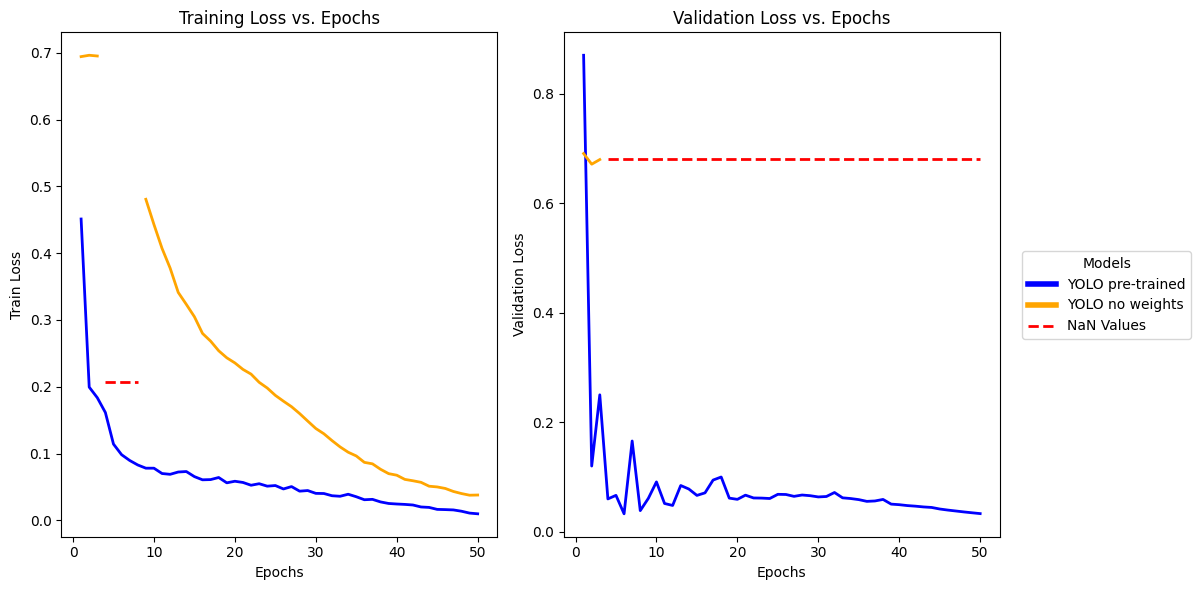

In [5]:
logs_dict = {
    "YOLO pre-trained": ("models/yolo_classifier.csv"),
    "YOLO no weights": ("models/yolo_no_weights.csv")
}

df_dict = {}
for model_name, file_path in logs_dict.items():
    df = pd.read_csv(file_path)
    df.rename(columns={"train/loss": "train_loss", "val/loss": "val_loss"}, inplace=True)
    df_dict[model_name] = df

colors = ["blue", "orange"]
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for (model_name, df), color in zip(df_dict.items(), colors):
    plt.plot(df['epoch'], df['train_loss'], label=model_name, linewidth=2, color=color, linestyle='solid')
    nan_mask = df['train_loss'].isna()
    plt.plot(df['epoch'][nan_mask], [df['train_loss'].mean()] * sum(nan_mask), linestyle='dashed', linewidth=2, color='red')
plt.xlabel("Epochs")
plt.ylabel("Train Loss")
plt.title("Training Loss vs. Epochs")

plt.subplot(1, 2, 2)
for (model_name, df), color in zip(df_dict.items(), colors):
    plt.plot(df['epoch'], df['val_loss'], label=model_name, linewidth=2, color=color, linestyle='solid')
    nan_mask = df['val_loss'].isna()
    plt.plot(df['epoch'][nan_mask], [df['val_loss'].mean()] * sum(nan_mask), linestyle='dashed', linewidth=2, color='red')
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs. Epochs")

handles = [plt.Line2D([0], [0], color=color, linewidth=4) for color in colors] + [plt.Line2D([0], [0], color="red", linestyle="dashed", linewidth=2)]
labels = list(logs_dict.keys()) + ["NaN Values"]
plt.figlegend(handles, labels, loc="center right", title="Models")
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

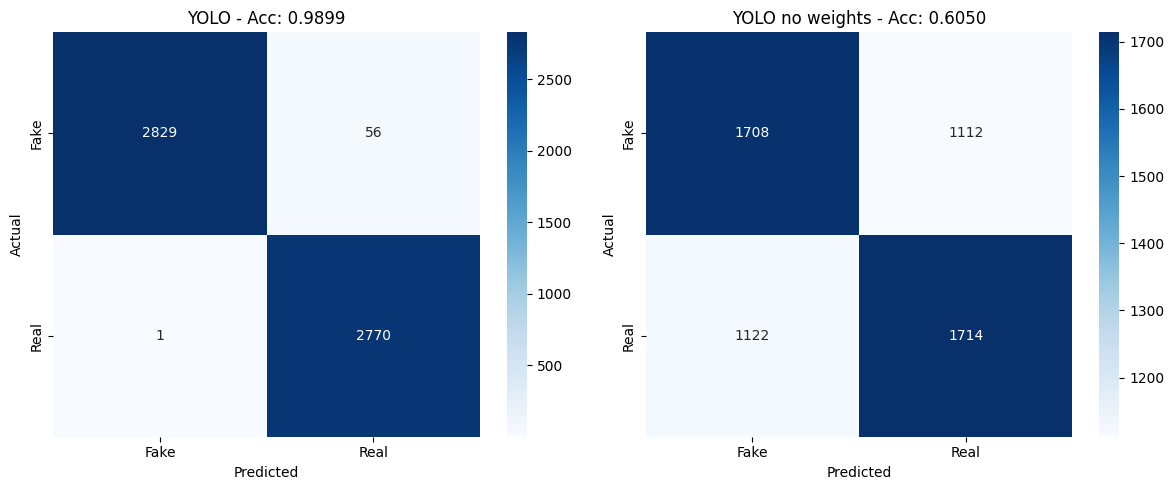

In [6]:
models_to_plot = ["YOLO", "YOLO no weights"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model_name in zip(axes, models_to_plot):
    data = results[model_name]
    cm = data["confusion_matrix"]
    
    if cm.dtype == np.float64 or cm.dtype == np.float32:
        cm = cm.astype(int)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{model_name} - Acc: {data['accuracy']:.4f}")

plt.tight_layout()
plt.show()

## CNN Resnet pre-trained vs 'raw'
- We can see that in the pre-trained CNN the model converges to a constant value loss. That is likely because the model overfits due to the huge amount of data that was used to pre-train it.
- Both models overfit a lot because we did not add dropout during training. That is one thing we can enhance in the future. The 'raw' model has almost the double of val_loss compared to the pre trained one.
- Once again the pre-trained model has a better accuracy which was expected.

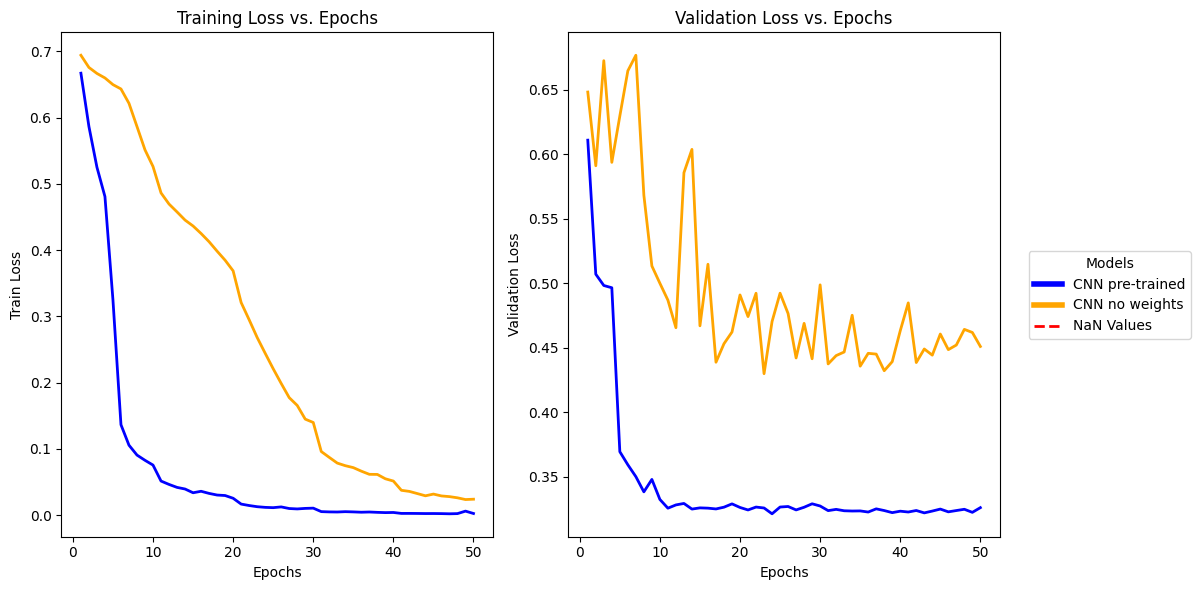

In [7]:
logs_dict = {
    "CNN pre-trained": ("models/resnet_classifier.csv"),
    "CNN no weights": ("models/resnet_no_weights.csv")
}

df_dict = {}
for model_name, file_path in logs_dict.items():
    df = pd.read_csv(file_path)
    df.rename(columns={"train/loss": "train_loss", "val/loss": "val_loss"}, inplace=True)
    df_dict[model_name] = df

colors = ["blue", "orange"]
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for (model_name, df), color in zip(df_dict.items(), colors):
    plt.plot(df['epoch'], df['train_loss'], label=model_name, linewidth=2, color=color, linestyle='solid')
    nan_mask = df['train_loss'].isna()
    plt.plot(df['epoch'][nan_mask], [df['train_loss'].mean()] * sum(nan_mask), linestyle='dashed', linewidth=2, color='red')
plt.xlabel("Epochs")
plt.ylabel("Train Loss")
plt.title("Training Loss vs. Epochs")

plt.subplot(1, 2, 2)
for (model_name, df), color in zip(df_dict.items(), colors):
    plt.plot(df['epoch'], df['val_loss'], label=model_name, linewidth=2, color=color, linestyle='solid')
    nan_mask = df['val_loss'].isna()
    plt.plot(df['epoch'][nan_mask], [df['val_loss'].mean()] * sum(nan_mask), linestyle='dashed', linewidth=2, color='red')
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs. Epochs")

handles = [plt.Line2D([0], [0], color=color, linewidth=4) for color in colors] + [plt.Line2D([0], [0], color="red", linestyle="dashed", linewidth=2)]
labels = list(logs_dict.keys()) + ["NaN Values"]
plt.figlegend(handles, labels, loc="center right", title="Models")
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

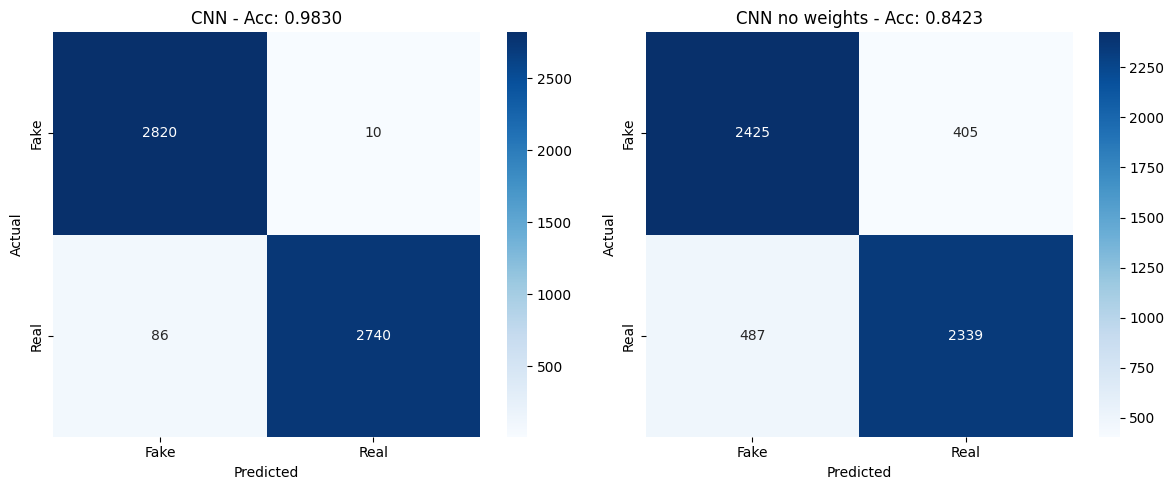

In [8]:
models_to_plot = ["CNN", "CNN no weights"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model_name in zip(axes, models_to_plot):
    data = results[model_name]
    cm = data["confusion_matrix"]
    
    if cm.dtype == np.float64 or cm.dtype == np.float32:
        cm = cm.astype(int)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{model_name} - Acc: {data['accuracy']:.4f}")

plt.tight_layout()
plt.show()

## ViT pre-trained vs 'raw' vs ViT pre-trained w/o dropout
- As expected ViT without dropout overfits much more than the model with dropout implemented.
- The dropout really helped the ViT model to improve its performance with an increase of 8% over the no dropout model.

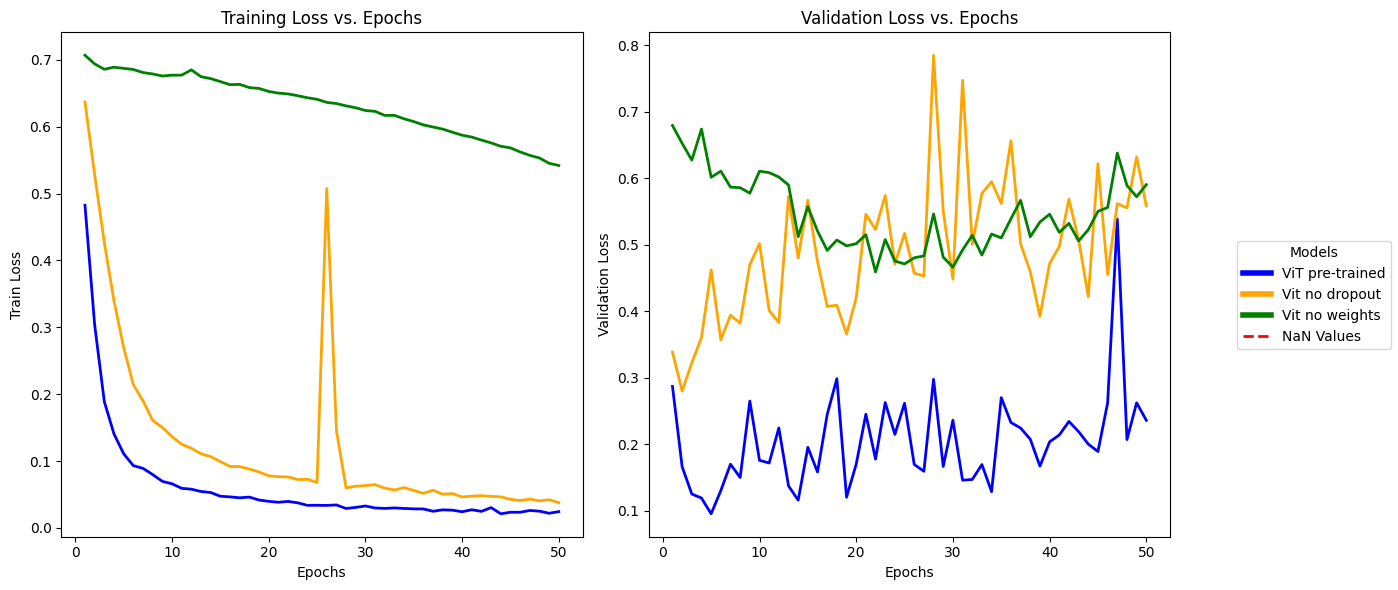

In [10]:
logs_dict = {
    "ViT pre-trained": ("models/vit_classifier.csv"),
    "Vit no dropout": ("models/vit_classifier_no_dropout.csv"),
    "Vit no weights": ("models/vit_classifier_no_weights.csv")
}

df_dict = {}
for model_name, file_path in logs_dict.items():
    df = pd.read_csv(file_path)
    df.rename(columns={"train/loss": "train_loss", "val/loss": "val_loss"}, inplace=True)
    df_dict[model_name] = df

colors = ["blue", "orange", "green"]
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for (model_name, df), color in zip(df_dict.items(), colors):
    plt.plot(df['epoch'], df['train_loss'], label=model_name, linewidth=2, color=color, linestyle='solid')
    nan_mask = df['train_loss'].isna()
    if nan_mask.any():
        plt.plot(df['epoch'][nan_mask], [df['train_loss'].mean()] * sum(nan_mask), linestyle='dashed', linewidth=2, color='red')
plt.xlabel("Epochs")
plt.ylabel("Train Loss")
plt.title("Training Loss vs. Epochs")

plt.subplot(1, 2, 2)
for (model_name, df), color in zip(df_dict.items(), colors):
    plt.plot(df['epoch'], df['val_loss'], label=model_name, linewidth=2, color=color, linestyle='solid')
    nan_mask = df['val_loss'].isna()
    if nan_mask.any():
        plt.plot(df['epoch'][nan_mask], [df['val_loss'].mean()] * sum(nan_mask), linestyle='dashed', linewidth=2, color='red')
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs. Epochs")

# Legend setup
handles = [plt.Line2D([0], [0], color=color, linewidth=4) for color in colors]
handles.append(plt.Line2D([0], [0], color="red", linestyle="dashed", linewidth=2))
labels = list(logs_dict.keys()) + ["NaN Values"]
plt.figlegend(handles, labels, loc="center right", title="Models")
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

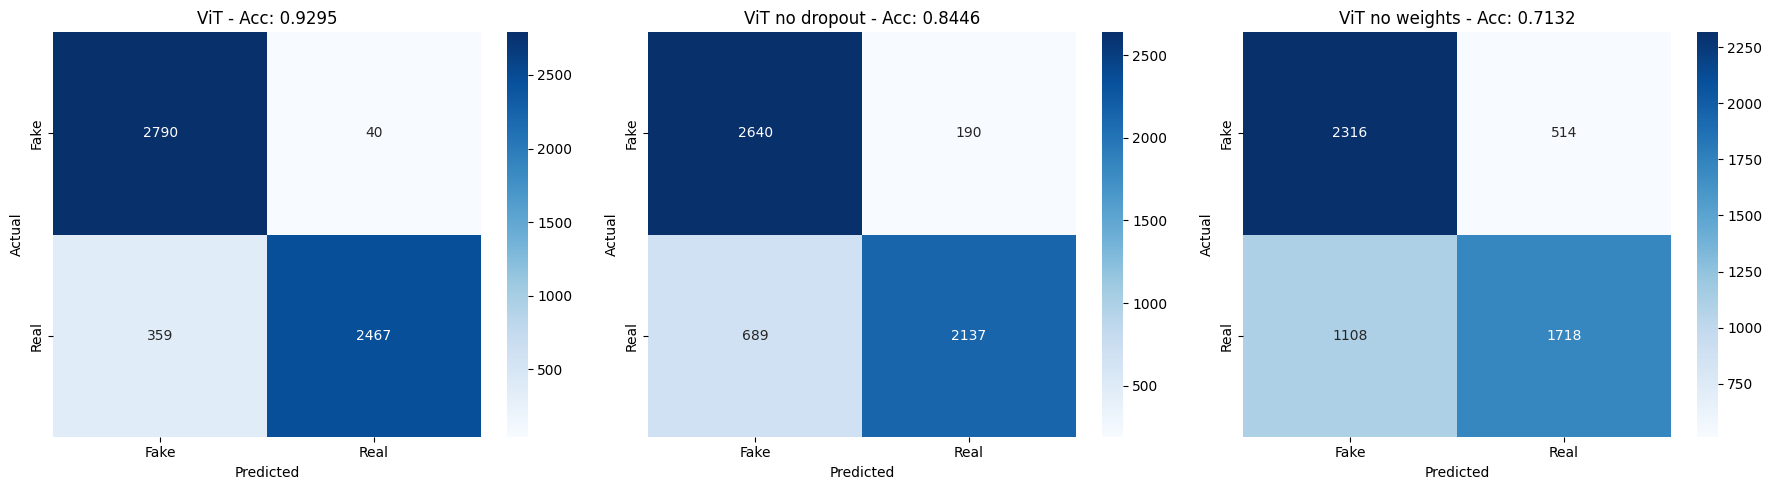

In [11]:
models_to_plot = ["ViT", "ViT no dropout", "ViT no weights"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, models_to_plot):
    data = results[model_name]
    cm = data["confusion_matrix"]
    
    if cm.dtype == np.float64 or cm.dtype == np.float32:
        cm = cm.astype(int)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{model_name} - Acc: {data['accuracy']:.4f}")

plt.tight_layout()
plt.show()

## All models acc and val_loss
- YOLO and CNN show great performance.
- Even though YOLO was pre-trained on huge amounts of data it doesn't overfit. Great model that generalizes well.
- YOLO no weights has problems to gather val_loss values even though no errors were noticed during training.

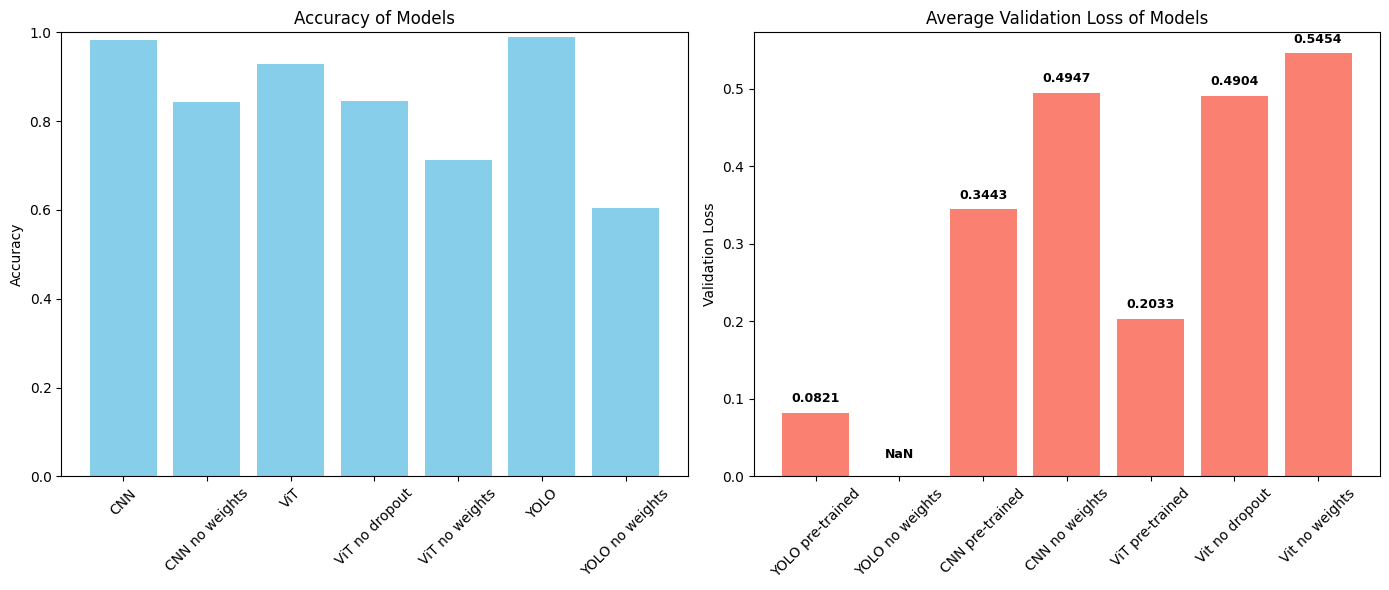

In [13]:
def plot_model_metrics(results, df_dict):
    # Use `results` keys for accuracy graph
    acc_model_names = list(results.keys())
    accuracies = [
        results[model]["accuracy"] if model in results else float('nan')
        for model in acc_model_names
    ]
    
    # Use `df_dict` keys for val loss graph
    loss_model_names = list(df_dict.keys())
    avg_val_losses = []
    val_loss_colors = []
    val_loss_labels = []

    for model in loss_model_names:
        val_losses = df_dict[model]["val_loss"]
        num_nans = val_losses.isna().sum()

        if num_nans > 5:  # More than 5 NaNs → set bar to 0 and label as NaN
            avg_val_losses.append(0)
            val_loss_colors.append('red')
            val_loss_labels.append("NaN")
        else:
            avg = val_losses.dropna().mean()
            avg_val_losses.append(avg)
            val_loss_colors.append('salmon')
            val_loss_labels.append(f"{avg:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Accuracy bar plot
    axes[0].bar(acc_model_names, accuracies, color='skyblue')
    axes[0].set_title("Accuracy of Models")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', rotation=45)

    # Validation Loss bar plot
    bars = axes[1].bar(loss_model_names, avg_val_losses, color=val_loss_colors)
    axes[1].set_title("Average Validation Loss of Models")
    axes[1].set_ylabel("Validation Loss")
    axes[1].tick_params(axis='x', rotation=45)

    # Add labels on top of each bar
    for bar, label in zip(bars, val_loss_labels):
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 if height > 0 else 0.02,
            label,
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

logs_dict = {
    "YOLO pre-trained": ("models/yolo_classifier.csv"),
    "YOLO no weights": ("models/yolo_no_weights.csv"),
    "CNN pre-trained": ("models/resnet_classifier.csv"),
    "CNN no weights": ("models/resnet_no_weights.csv"),
    "ViT pre-trained": ("models/vit_classifier.csv"),
    "Vit no dropout": ("models/vit_classifier_no_dropout.csv"),
    "Vit no weights": ("models/vit_classifier_no_weights.csv")
}

df_dict = {}
for model_name, file_path in logs_dict.items():
    df = pd.read_csv(file_path)
    df.rename(columns={"train/loss": "train_loss", "val/loss": "val_loss"}, inplace=True)
    df_dict[model_name] = df

plot_model_metrics(results, df_dict)